In [ ]:
# from qiskit.circuit.library import zz_feature_map
# qc.append(zz_feature_map(2,1),[0,1])
# qc.decompose().draw('mpl')

In [7]:
# import numpy as np
# thetas = np.random.uniform(0, np.pi, size=4)
# qc = build_zzfeaturemap_circuit(thetas,reps=2,entanglement="full")
# qc.decompose().draw('mpl')

In [8]:
# qc.assign_parameters({qc.parameters[0]: 0.5, qc.parameters[1]: 0.5})


In [ ]:
"""
(1) amplitude encoding: RY
(2) basis mixing: H
(3) entanglement in rotated basis: RZZ
(4) decoding to observable space : H
"""
thetas = np.random.uniform(0, np.pi, size=4)
qq = build_correlated_circuit(thetas, theta_rzz=np.pi/2)
qq.draw('mpl')

# 4 Qubits

## Baseline 

In [ ]:
مدل پایه روی داده‌های مستقل (دوران تصادفی) آموزش می‌بیند.
ارزیابی روی دو نوع داده تست انجام می‌شود: داده مستقل و داده همبسته با RZZ.
نمودارها و شاخص‌ها (شاخص ها) طوری نمایش داده می‌شوند که قابلیت مقایسه مستقیم با مدل‌های پیچیده‌تر در آینده وجود داشته باشد.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit.circuit.library import zz_feature_map

# ============================================================
# INDEPENDENT CIRCUIT

def build_circuit_independent( thetas,measure=True,**kwargs):

    qc = QuantumCircuit(4, 4)

    for i in range(4):
        qc.ry(thetas[i], i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# RZZ CORRELATED CIRCUIT
def build_correlated_circuit(
    thetas,theta_rzz=np.pi/2,
    measure=True,**kwargs):

    qc = QuantumCircuit(4, 4)
    # amplitude encoding
    for i in range(4):
        qc.ry(thetas[i], i)
    # basis rotation
    for i in range(4):
        qc.h(i)
    # entangling layer
    for j in range(4):
        for k in range(j+1, 4):
            qc.rzz(theta_rzz, j, k)
    # return basis
    for i in range(4):
        qc.h(i)
    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc

# ============================================================
# ZZ FEATURE MAP CIRCUIT
# ============================================================


def build_zzfeaturemap_circuit(
    thetas,reps=2,entanglement="full",
    measure=True, **kwargs):

    feature_map = zz_feature_map(
        feature_dimension=4,
        reps=reps,entanglement=entanglement)
    qc = QuantumCircuit(4, 4)
    qc.compose(
        feature_map.assign_parameters(thetas),
        inplace=True )

    if measure:
        qc.measure([0,1,2,3], [0,1,2,3])
    return qc


In [ ]:
# ============================================================
# IMPORTS
import os
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
from qiskit import transpile
# GLOBAL CONFIG
# ============================================================

NUM_QUBITS = 4
DATA_ROOT = "./DataTrain"
# CIRCUIT REGISTRY
# ============================================================
CIRCUIT_BUILDERS = {"independent": build_circuit_independent,
    "zz_rzz": build_correlated_circuit,
    "zz_featuremap": build_zzfeaturemap_circuit,}
# NOISE MODEL REGISTRY
# ============================================================
NOISE_MODES = {"synthetic","experimental_single","experimental_correlated"}
# CREATE NOISE MODEL
# ============================================================
def create_noise_model(mode="synthetic",p01=0.05,p10=0.05,
    single_qubit_dir="./noise_matrix_results",
    correlated_matrix_path="./noise_matrix_results/noise_matrix_16x16.npy"):
    """Create noise model.
    MODES
    synthetic:
        Same readout error on all qubits.
    experimental_single:
        Uses independent 2x2 assignment matrices
        extracted from experimental data.
    experimental_correlated:
        Uses full correlated 16x16 readout matrix. """
    noise_model = NoiseModel()
    # SYNTHETIC
    if mode == "synthetic":
        readout_error = ReadoutError([
            [1-p01, p01],
            [p10, 1-p10] ])
        for q in range(NUM_QUBITS):
            noise_model.add_readout_error(
                readout_error,[q] )
    # EXPERIMENTAL SINGLE-QUBIT
    elif mode == "experimental_single":
        for q in range(NUM_QUBITS):
            path = os.path.join(single_qubit_dir,
                f"assignment_matrix_q{q+1}.npy")
            A = np.load(path)
            readout_error = ReadoutError(A)
            noise_model.add_readout_error(
                readout_error,[q])
    # EXPERIMENTAL CORRELATED
    elif mode == "experimental_correlated":
        A16 = np.load(correlated_matrix_path)
        readout_error = ReadoutError(A16)
        noise_model.add_readout_error(
            readout_error,[0,1,2,3])
    else:
        raise ValueError(f"Unknown noise mode: {mode}")
    return noise_model
# COUNTS -> PROBABILITIES
# ============================================================
def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count
    return probs / np.sum(probs)
# RUN CIRCUIT
# ============================================================
def get_probs(
    circuit_builder,
    thetas,noise_model=None,
    shots=1024,**circuit_kwargs):
    qc = circuit_builder(
        thetas,**circuit_kwargs)
    sim = AerSimulator(noise_model=noise_model)
    qc_t = transpile(qc, sim)
    result = sim.run( qc_t,shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)
# GENERATE DATASET
# ============================================================
def generate_dataset(
    num_samples,
    circuit_type="independent",
    noise_mode="synthetic",
    shots=1024,noise_kwargs=None,
    circuit_kwargs=None):
    """ Generate dataset.
    INPUT:
    circuit_type:
        independent
        zz_rzz
        zz_featuremap
    noise_mode:
        synthetic
        experimental_single
        experimental_correlated """
    if noise_kwargs is None:
        noise_kwargs = {}
    if circuit_kwargs is None:
        circuit_kwargs = {}
    if circuit_type not in CIRCUIT_BUILDERS:
        raise ValueError("Unknown circuit type")
    circuit_builder = CIRCUIT_BUILDERS[circuit_type]
    X, Y, THETAS  = [], [], []
    for _ in range(num_samples):
        thetas = np.random.uniform(
            0,np.pi, size=NUM_QUBITS )
        # CREATE NOISE MODEL
        # --------------------------------------------
        if noise_mode == "synthetic":
            p01 = np.random.uniform(
                noise_kwargs.get("p01_min", 0.05),
                noise_kwargs.get("p01_max", 0.15))
            p10 = np.random.uniform(
                noise_kwargs.get("p10_min", 0.05),
                noise_kwargs.get("p10_max", 0.15) )
            noise_model = create_noise_model(
                mode="synthetic", p01=p01,p10=p10)
        else:
            noise_model = create_noise_model(
                mode=noise_mode)
        # IDEAL
        # --------------------------------------------
        p_ideal = get_probs(
            circuit_builder,
            thetas,
            noise_model=None,
            shots=shots,
            **circuit_kwargs)      
        # NOISY
        # --------------------------------------------
        p_noisy = get_probs(
            circuit_builder,
            thetas,noise_model=noise_model,
            shots=shots,**circuit_kwargs )
        X.append(p_noisy)
        Y.append(p_ideal)
        THETAS.append(thetas)
    return (np.array(X),np.array(Y), np.array(THETAS))
# SAVE DATASET
# ============================================================
def save_dataset(
    X,Y,THETAS,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic"):
    """ Save dataset to:
     DataTrain/
        circuit_type/
            noise_mode/ """
    save_dir = os.path.join(
        DATA_ROOT,circuit_type, noise_mode )
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, f"X_{split}.npy"),X)
    np.save(os.path.join(save_dir, f"Y_{split}.npy"),Y )
    np.save(os.path.join(save_dir, f"theta_{split}.npy"),THETAS)
    print("\nSaved dataset:")
    print(save_dir)
# LOAD DATASET
# ============================================================
def load_dataset(split="train",circuit_type="independent",
    noise_mode="synthetic"):
    load_dir = os.path.join(DATA_ROOT,circuit_type,noise_mode)
    X = np.load(os.path.join(load_dir, f"X_{split}.npy"))
    Y = np.load(os.path.join(load_dir, f"Y_{split}.npy"))
    THETAS = np.load(
        os.path.join(load_dir, f"theta_{split}.npy"))
    print("\nLoaded dataset:")
    print(load_dir)
    print("\nShapes:")
    print("X:", X.shape)
    print("Y:", Y.shape)
    print("THETAS:", THETAS.shape)
    return X, Y, THETAS
# BUILD + SAVE DATASET
# ============================================================
def build_and_save_dataset(
    num_samples,split="train",circuit_type="independent",
    noise_mode="synthetic",shots=1024,noise_kwargs=None,
    circuit_kwargs=None):

    print("GENERATING DATASET")
    print("================================================")
    print("Circuit :", circuit_type)
    print("Noise   :", noise_mode)
    print("Samples :", num_samples)
    X, Y, THETAS = generate_dataset(
        num_samples=num_samples,
        circuit_type=circuit_type,
        noise_mode=noise_mode,
        shots=shots,noise_kwargs=noise_kwargs,
        circuit_kwargs=circuit_kwargs)
    save_dataset(X,Y,THETAS,
        split=split,circuit_type=circuit_type,noise_mode=noise_mode)

    return X, Y, THETAS

In [ ]:
# ============================================================
# EXAMPLE 1
# independent + synthetic
# ============================================================
X, Y, TH = build_and_save_dataset(
    num_samples=4000,
    split="train",
    circuit_type="independent",
    noise_mode="synthetic")

In [ ]:
# ============================================================
# EXAMPLE 2
# ZZ RZZ + experimental correlated
# ============================================================

X, Y, TH = build_and_save_dataset(
    num_samples=2000,
    split="test",
    circuit_type="zz_rzz",
    noise_mode="experimental_correlated",
    circuit_kwargs={"theta_rzz": np.pi/2})

In [ ]:
# ============================================================
# EXAMPLE 3
# ZZFeatureMap + experimental single
# ============================================================

X, Y, TH = build_and_save_dataset(
    num_samples=3000,
    split="train",
    circuit_type="zz_featuremap",
    noise_mode="experimental_single",
    circuit_kwargs={
        "reps": 2,"entanglement": "full"})

In [ ]:
# ============================================================
# LOAD
# ============================================================

X_train, Y_train, TH_train = load_dataset(
    split="train",circuit_type="zz_featuremap",
    noise_mode="experimental_single")

In [1]:
# NOISE MODEL FACTORY
# Supports:
#   mode="synthetic" (Qiskit Aer's ReadoutError)
#   mode="experimental_single" (uses 4 separate 2x2 assignment matrices yeilded from LDA)
#   mode="experimental_correlated" (uses a single 16x16 noise matrix yeilded from LDA)

import os
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
# from qiskit.circuit.library.data_preparation import ZZFeatureMap
from qiskit.circuit.library import zz_feature_map
# ============================================================
# DEFAULT PATHS
NOISE_DIR = "./noise_matrix_results"
# ============================================================
# ================================
# METRICS
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10) / (q + 1e-10)))
def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2
def l1_error(p, q):
    return np.sum(np.abs(p - q))
# ================================
# CIRCUIT BUILDERS
# RY → H → RZZ → H
def build_circuit_independent(thetas):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc
def build_correlated_circuit(thetas, theta_rzz=np.pi/2):
    qc = QuantumCircuit(4, 4) 
    # 1) amplitude encoding
    for i in range(4):
        qc.ry(thetas[i], i)
    # 2) basis rotation (Z → X basis mix)
    for i in range(4):
        qc.h(i)
    # 3) entangling layer
    for j in range(4):
        for k in range(j+1, 4):
            qc.rzz(theta_rzz, j, k)
    # 4) Return to observable basis
    for i in range(4):
        qc.h(i)
    # measurement
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# ============================================================
# BUILD ZZFeatureMap CIRCUIT
# ============================================================
def build_zzfeaturemap_circuit(thetas,reps=1,entanglement="full"):
    """ Build a 4-qubit circuit using Qiskit's ZZFeatureMap.
    Parameters
        thetas : array-like, shape (4,)
        Input feature vector.
    reps : int
        Number of repeated feature-map layers.
    entanglement : str
        Entanglement structure:
            "full"
            "linear"
            "circular"
    Returns
        qc : QuantumCircuit """
    # -------------------------------------------------------
    # CREATE FEATURE MAP
    feature_map = zz_feature_map(feature_dimension=4,
        reps=reps, entanglement=entanglement )
    # --------------------------------------------------------
    # ASSIGN PARAMETERS
    qc_feature = feature_map.assign_parameters(thetas)
    qc = QuantumCircuit(4, 4)
    qc.compose( qc_feature, inplace=True )
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc
# LOAD SINGLE-QUBIT MATRICES
def load_single_qubit_assignment_matrices(
    noise_dir=NOISE_DIR,num_qubits=4):
    matrices = []
    for q in range(num_qubits):
        path = os.path.join(noise_dir,f"assignment_matrix_q{q+1}.npy")
        A = np.load(path)
        if A.shape != (2,2):
            raise ValueError(f"{path} is not 2x2")
        matrices.append(A)
    return matrices
# ============================================================
# LOAD FULL 16x16 MATRIX
def load_correlated_noise_matrix(noise_dir=NOISE_DIR):
    path = os.path.join(noise_dir,"noise_matrix_16x16.npy" )
    A = np.load(path)
    if A.shape != (16,16):
        raise ValueError("Noise matrix must be 16x16")
    return A
# ============================================================
# CREATE NOISE MODEL
def create_noise_model(mode="synthetic",noise_range=(0.05,0.15),noise_dir=NOISE_DIR):
    """Supported modes
    synthetic
            [[1-p01, p01],
             [p10, 1-p10]]
    experimental_single
            assignment_matrix_q1.npy
            ...
            assignment_matrix_q4.npy
    experimental_correlated
            noise_matrix_16x16.npy  """
    noise_model = NoiseModel()
    # ========================================================
    # MODE 1: SYNTHETIC PARAMETRIC MODEL
    if mode == "synthetic":
        p01 = np.random.uniform(*noise_range),
        p10 = np.random.uniform(*noise_range),
        A = np.array([
            [1-p01, p01],
            [p10, 1-p10] ])
        readout_error = ReadoutError(A)
        for q in range(4):
            noise_model.add_readout_error(readout_error,[q])
    # ========================================================
    # MODE 2: EXPERIMENTAL INDEPENDENT
    elif mode == "experimental_single":
        assignment_matrices = (load_single_qubit_assignment_matrices(
                noise_dir=noise_dir))
        for q, A in enumerate(assignment_matrices):
            readout_error = ReadoutError(A)
            noise_model.add_readout_error(readout_error,[q])
    # ========================================================
    # MODE 3: EXPERIMENTAL CORRELATED
    elif mode == "experimental_correlated":
        A16 = load_correlated_noise_matrix(noise_dir=noise_dir)
        readout_error = ReadoutError(A16)
        noise_model.add_readout_error(readout_error,[0,1,2,3])
    # ========================================================
    # UNKNOWN MODE
    else:
        raise ValueError(f"Unknown mode: {mode}" )
    return noise_model
def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count
    return probs / np.sum(probs)
# ================================
def get_probs(qc_func, thetas, noise_model=None, shots=1024):
    qc = qc_func(thetas)
    sim = AerSimulator(noise_model=noise_model)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)
# ============================================================
# DATA GENERATION
def generate_dataset(num_samples,qc_func,
    noise_model=None, shots=1024):
    X , Y = [], []
    Thetas = []
    for _ in range(num_samples):
        thetas = np.random.uniform( 0,np.pi,size=4)
        # IDEAL
        p_ideal = get_probs(qc_func, thetas,
            noise_model=None, shots=shots )
        # --------------------------------------------
        # NOISY
        p_noisy = get_probs(qc_func,thetas,
            noise_model=noise_model, shots=shots)
        X.append(p_noisy)
        Y.append(p_ideal)
        Thetas.append(thetas)
    return (np.array(X),
            np.array(Y),
            np.array(Thetas))

### Save datasetsm

In [2]:
# DATASET STORAGE SYSTEM
# DATA DIRECTORY
DATASET_DIR = "./DataTrain"
os.makedirs(DATASET_DIR, exist_ok=True)
# SAVE DATASET
# ============================================================
def save_dataset( X,Y,Thetas,dataset_name):
    """ Save dataset into ./DataTrain/
    Example:
        dataset_name = "train_independent"
        dataset_name = "test_rzz"
        dataset_name = "test_zzfeaturemap" """
    # FILE PATHS
    # --------------------------------------------------------
    x_path = os.path.join(DATASET_DIR,f"X_{dataset_name}.txt" )
    y_path = os.path.join(DATASET_DIR,f"Y_{dataset_name}.txt" )
    theta_path = os.path.join(DATASET_DIR,f"Thetas_{dataset_name}.txt")
    # SAVE
    np.savetxt(x_path, X.reshape(X.shape[0], -1))
    np.savetxt(y_path, Y.reshape(Y.shape[0], -1))
    np.savetxt(theta_path,Thetas)
    print("DATASET SAVED")
    print("================================================")
    print("X saved to :", x_path)
    print("Y saved to :", y_path)
    print("Theta saved to :", theta_path)
# LOAD DATASET
# ============================================================
def load_dataset(dataset_name):
    """Load dataset from ./DataTrain/
    Returns:
        X, Y, Thetas """
    # FILE PATHS
    x_path = os.path.join(DATASET_DIR,f"X_{dataset_name}.txt" )
    y_path = os.path.join(DATASET_DIR,f"Y_{dataset_name}.txt" )
    theta_path = os.path.join(DATASET_DIR,f"Thetas_{dataset_name}.txt")
    # LOAD
    X = np.loadtxt(x_path).reshape(-1, 16)
    Y = np.loadtxt(y_path).reshape(-1, 16)
    Thetas = np.loadtxt(theta_path).reshape(-1, 4)
    print("DATASET LOADED")
    print("================================================")
    print("Dataset:", dataset_name)
    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Theta shape:", Thetas.shape)
    return X, Y, Thetas

### Generate and save datasets

In [ ]:
# GENERATE DATASETS :  Independent
print("\nGenerating TRAIN dataset (independent)...")
X_train_ind, Y_train_ind, theta_train_ind = generate_dataset(
    4000, build_circuit_independent)

save_dataset(X_train_ind,Y_train_ind,theta_train_ind,"train_independent")
# 30 min compile time


Generating TRAIN dataset (independent)...
DATASET SAVED
X saved to : ./DataTrain\X_train_independent.txt
Y saved to : ./DataTrain\Y_train_independent.txt
Theta saved to : ./DataTrain\Thetas_train_independent.txt


In [ ]:
# Manual RZZ
X_train_rzz, Y_train_rzz, theta_train_rzz = generate_dataset(
    4000,build_correlated_circuit)

save_dataset(X_train_rzz,Y_train_rzz,theta_train_rzz,"train_rzz")
# 30 min compile time

DATASET SAVED
X saved to : ./DataTrain\X_train_rzz.txt
Y saved to : ./DataTrain\Y_train_rzz.txt
Theta saved to : ./DataTrain\Thetas_train_rzz.txt


In [ ]:
# ZZFeatureMap
X_train_zzfm, Y_train_zzfm, theta_train_zzfm = generate_dataset(
    4000, build_zzfeaturemap_circuit)

save_dataset(X_train_zzfm,Y_train_zzfm,theta_train_zzfm,"train_zzfeaturemap")
# 30 min compile time

DATASET SAVED
X saved to : ./DataTrain\X_train_zzfeaturemap.txt
Y saved to : ./DataTrain\Y_train_zzfeaturemap.txt
Theta saved to : ./DataTrain\Thetas_train_zzfeaturemap.txt


In [6]:
# ============================================================
# BUILD MIXED TRAIN DATASET
# ============================================================
X_train_mixed = np.vstack([X_train_ind,X_train_rzz,X_train_zzfm])
Y_train_mixed = np.vstack([Y_train_ind,Y_train_rzz,Y_train_zzfm])
theta_train_mixed = np.vstack([theta_train_ind,theta_train_rzz,theta_train_zzfm])

save_dataset(X_train_mixed,Y_train_mixed,theta_train_mixed,"train_mixed")

DATASET SAVED
X saved to : ./DataTrain\X_train_mixed.txt
Y saved to : ./DataTrain\Y_train_mixed.txt
Theta saved to : ./DataTrain\Thetas_train_mixed.txt


In [ ]:
#  TEST dataset (independent)
# ============================================================
print("\nGenerating TEST dataset (independent)...")
X_test_ind, Y_test_ind, theta_test_ind = generate_dataset(
    1300, build_circuit_independent)

save_dataset(X_test_ind,Y_test_ind, theta_test_ind,"test_independent")
# 9 min compile time


Generating TEST dataset (independent)...
DATASET SAVED
X saved to : ./DataTrain\X_test_independent.txt
Y saved to : ./DataTrain\Y_test_independent.txt
Theta saved to : ./DataTrain\Thetas_test_independent.txt


In [8]:
# Test dataset (manual RZZ)
# ============================================================
print("\nGenerating TEST dataset (manual RZZ)...")
X_test_rzz, Y_test_rzz, theta_test_rzz = generate_dataset(
    1300,build_correlated_circuit)

save_dataset( X_test_rzz,Y_test_rzz,theta_test_rzz,"test_rzz")


Generating TEST dataset (manual RZZ)...
DATASET SAVED
X saved to : ./DataTrain\X_test_rzz.txt
Y saved to : ./DataTrain\Y_test_rzz.txt
Theta saved to : ./DataTrain\Thetas_test_rzz.txt


In [9]:
# Test dataset (ZZFeatureMap)
# ============================================================
print("\nGenerating TEST dataset (ZZFeatureMap)...")
X_test_zzfm, Y_test_zzfm, theta_test_zzfm = generate_dataset(
    1300, build_zzfeaturemap_circuit)

save_dataset(X_test_zzfm,Y_test_zzfm, theta_test_zzfm,"test_zzfeaturemap")
print("\nAll datasets generated successfully.")


Generating TEST dataset (ZZFeatureMap)...
DATASET SAVED
X saved to : ./DataTrain\X_test_zzfeaturemap.txt
Y saved to : ./DataTrain\Y_test_zzfeaturemap.txt
Theta saved to : ./DataTrain\Thetas_test_zzfeaturemap.txt

All datasets generated successfully.


In [10]:
# ============================================================
# BUILD MIXED TEST DATASET
# ============================================================
X_test_mixed = np.vstack([X_test_ind, X_test_rzz,X_test_zzfm])
Y_test_mixed = np.vstack([Y_test_ind,Y_test_rzz,Y_test_zzfm])
theta_test_mixed = np.vstack([theta_test_ind,theta_test_rzz,theta_test_zzfm])

save_dataset(X_test_mixed,Y_test_mixed,theta_test_mixed,"test_mixed")

DATASET SAVED
X saved to : ./DataTrain\X_test_mixed.txt
Y saved to : ./DataTrain\Y_test_mixed.txt
Theta saved to : ./DataTrain\Thetas_test_mixed.txt


### Load datasets

In [ ]:
# LOAD TRAIN DATA
X_train_ind, Y_train_ind, theta_train_ind = load_dataset("train_independent")
# LOAD TEST DATASETS
# ============================================================
X_test_ind, Y_test_ind, theta_test_ind = load_dataset("test_independent")
X_test_rzz, Y_test_rzz, theta_test_rzz = load_dataset("test_rzz")
X_test_zzfm, Y_test_zzfm, theta_test_zzfm = load_dataset("test_zzfeaturemap")

# previous method! 

### SAVE DATA

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(16, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 16),
            
            nn.Softmax(dim=1))
    
    
    def forward(self, x):
        return self.net(x)

In [5]:
# ================================
# DATA LOADERS
# ================================
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_b,dtype=torch.float32),
                  torch.tensor(Y_train_b,dtype=torch.float32)),
    batch_size=64, shuffle=True
)

In [6]:
# ================================
# TRAINING
# ================================
model_base = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model_base.parameters(), lr=1e-3)

epochs = 71
train_losses, test_losses = [], []

for epoch in range(epochs):
    model_base.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_base(x_batch)
        loss = criterion(torch.log(preds + 1e-8), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))
    
    model_base.eval()
    with torch.no_grad():
        preds_test = model_base(torch.tensor(X_test_ind, dtype=torch.float32))
        test_loss = criterion(torch.log(preds_test + 1e-8),
                              torch.tensor(Y_test_ind, dtype=torch.float32)).item()
        test_losses.append(test_loss)
    if (epoch % 10) == 0:
        print(f"Epoch {epoch}: Train={train_losses[-1]:.5f}, Test={test_losses[-1]:.5f}")

Epoch 0: Train=0.90876, Test=0.21256
Epoch 10: Train=0.05116, Test=0.05053
Epoch 20: Train=0.03643, Test=0.03685
Epoch 30: Train=0.03415, Test=0.03514
Epoch 40: Train=0.03412, Test=0.03406
Epoch 50: Train=0.03347, Test=0.03404
Epoch 60: Train=0.03309, Test=0.03360
Epoch 70: Train=0.03299, Test=0.03355


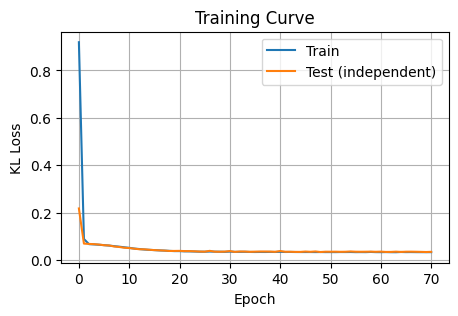

In [38]:
# ================================
# PLOT LOSS CURVE
# ================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test (independent)")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ================================
# EVALUATION FUNCTION
# ================================
def evaluate_model(model, X, Y):
    fids, l1s, kls = [], [], []
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            pred = model(torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)).numpy().flatten()
            true = Y[i]
            fids.append(fidelity(true,pred))
            l1s.append(l1_error(true,pred))
            kls.append(kl_divergence(true,pred))
    return np.array(fids), np.array(l1s), np.array(kls)

fids_ind, l1_ind, kl_ind = evaluate_model(model_base, X_test_ind, Y_test_ind)
fids_zz, l1_zz, kl_zz = evaluate_model(model_base, X_test_zz, Y_test_zz)
fids_mix, l1_mix, kl_mix = evaluate_model(model_base, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind):<10.4f} | {np.mean(l1_ind):<10.4f} | {np.mean(kl_ind):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz):<10.4f} | {np.mean(l1_zz):<10.4f} | {np.mean(kl_zz):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix):<10.4f} | {np.mean(l1_mix):<10.4f} | {np.mean(kl_mix):<12.4f}")


===== TEST METRICS =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9798     | 0.1481     | 0.0341      
RZZ Correlated  | 0.7101     | 0.8796     | 0.5955      
Combined        | 0.8449     | 0.5138     | 0.3148      


In [9]:
# ================================
# EVALUATION FUNCTION
# ================================
def evaluate_model(model, X, Y):
    fids, l1s, kls = [], [], []
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            pred = model(torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)).numpy().flatten()
            true = Y[i]
            fids.append(fidelity(true,pred))
            l1s.append(l1_error(true,pred))
            kls.append(kl_divergence(true,pred))
    return np.array(fids), np.array(l1s), np.array(kls)

fids_ind, l1_ind, kl_ind = evaluate_model(model_base, X_test_ind, Y_test_ind)
fids_zz, l1_zz, kl_zz = evaluate_model(model_base, X_test_zz, Y_test_zz)
fids_mix, l1_mix, kl_mix = evaluate_model(model_base, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind):<10.4f} | {np.mean(l1_ind):<10.4f} | {np.mean(kl_ind):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz):<10.4f} | {np.mean(l1_zz):<10.4f} | {np.mean(kl_zz):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix):<10.4f} | {np.mean(l1_mix):<10.4f} | {np.mean(kl_mix):<12.4f}")


===== TEST METRICS =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9794     | 0.1466     | 0.0335      
RZZ Correlated  | 0.9795     | 0.1473     | 0.0335      
Combined        | 0.9795     | 0.1470     | 0.0335      


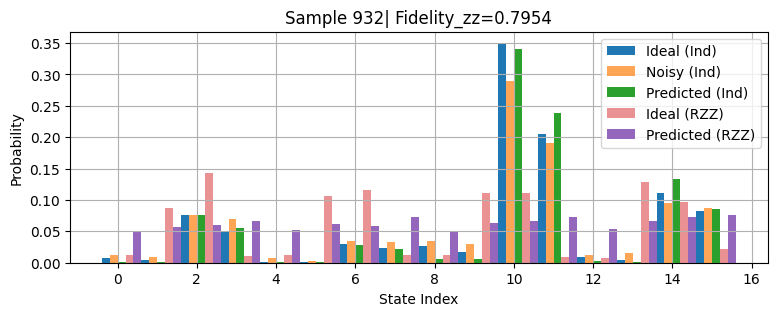

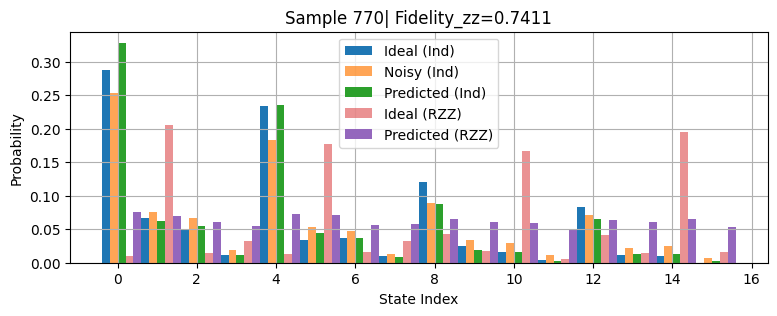

In [27]:
# ================================
# VISUAL COMPARISON (SAMPLE)
# ================================
indices = np.random.choice(len(X_test_ind), 2, replace=False)
for idx in indices:
    x_axis = np.arange(16)
    pred_ind = model_base(torch.tensor(X_test_ind[idx],dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    pred_zz  = model_base(torch.tensor(X_test_zz[idx],dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    true = Y_test_zz[idx]
    f = fidelity(true, pred_zz)
    width = 0.2
    plt.figure(figsize=(9,3))
    plt.bar(x_axis - 1.5*width, Y_test_ind[idx], width=width, label="Ideal (Ind)")
    plt.bar(x_axis - 0.5*width, X_test_ind[idx], width=width, alpha=0.7, label="Noisy (Ind)")
    plt.bar(x_axis + 0.5*width, pred_ind, width=width, label="Predicted (Ind)")
    plt.bar(x_axis + 1.5*width, Y_test_zz[idx], width=width, alpha=0.5, label="Ideal (RZZ)")
    plt.bar(x_axis + 2.5*width, pred_zz, width=width, label="Predicted (RZZ)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx}| Fidelity_zz={f:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

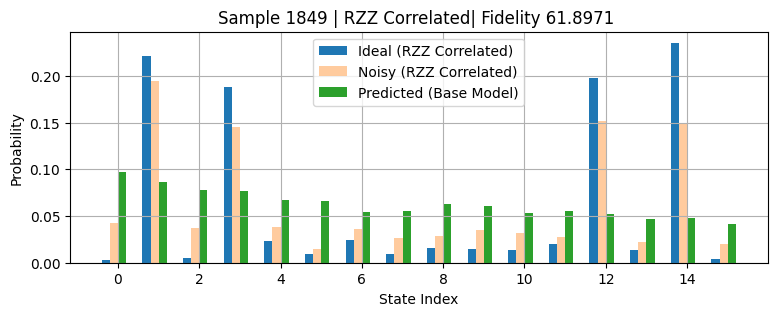

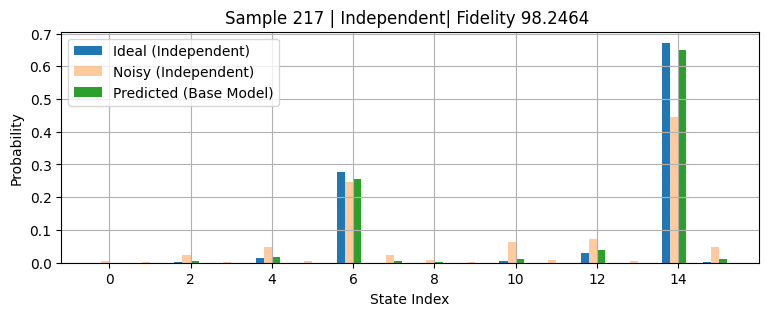

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch
# تعداد نمونه‌هایی که می‌خواهیم نمایش دهیم
num_samples_to_plot = 2
indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)
x_axis = np.arange(16)
width = 0.2

for idx in indices:
    # تعیین نوع نمونه
    label_type = "Independent" if idx < 1000 else "RZZ Correlated"
    plt.figure(figsize=(9,3))
    # ستون‌های نمودار
    plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
    plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    # پیش‌بینی مدل پایه
    pred = model_base(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    f = fidelity(Y_test_combined[idx], pred)
    plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (Base Model)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx} | {label_type}| Fidelity {100*f:.4f} ")
    plt.legend()
    plt.grid()
    plt.show()

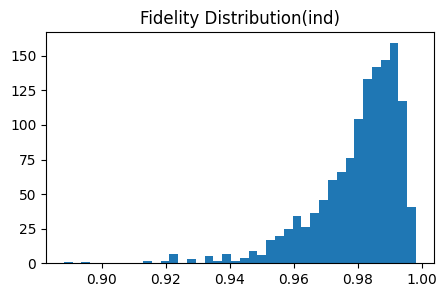

In [41]:
plt.figure(figsize=(5,3))
plt.hist(fids_ind, bins=40)
plt.title("Fidelity Distribution(ind)")
plt.show()

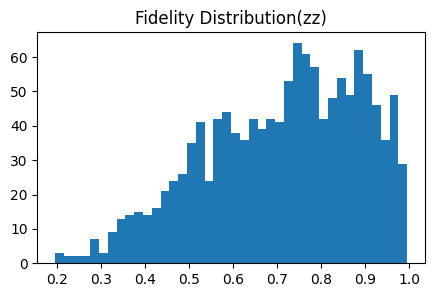

In [42]:
plt.figure(figsize=(5,3))
plt.hist(fids_zz, bins=40)
plt.title("Fidelity Distribution(zz)")
plt.show()

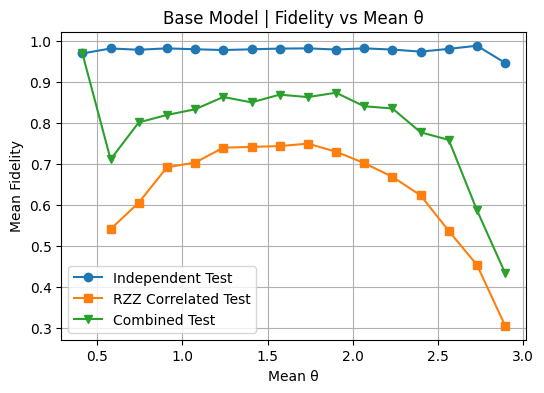

In [43]:
# ================================
# EVALUATION METRICS vs Base Model
# ================================
def compute_metric_vs_theta(X, Y, theta_array, model, metric='fidelity', num_bins=20):
    model.eval()
    values, theta_mean_list = [], []
    with torch.no_grad():
        for i in range(len(X)):
            x = torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)
            pred = model(x).numpy().flatten()
            true = Y[i]
            theta_mean = np.mean(theta_array[i])
            theta_mean_list.append(theta_mean)
            if metric=='fidelity':
                values.append(fidelity(true,pred))
            elif metric=='kl':
                values.append(kl_divergence(true,pred))
    theta_mean_list = np.array(theta_mean_list)
    values = np.array(values)
    bins = np.linspace(0,np.pi,num_bins)
    bin_centers = 0.5*(bins[:-1]+bins[1:])
    values_binned = []
    for i in range(len(bins)-1):
        mask = (theta_mean_list>=bins[i]) & (theta_mean_list<bins[i+1])
        values_binned.append(np.mean(values[mask]) if np.any(mask) else np.nan)
    return bin_centers, np.array(values_binned)
# ================================
# Fidelity comparison

# محاسبه برای دیتاست مستقل
# ================================
bin_centers_ind, fid_binned_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_base, 'fidelity')
# ================================
# محاسبه برای دیتاست RZZ
# ================================
bin_centers_zz, fid_binned_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity')
# ================================
# محاسبه برای دیتاست ترکیبی combined
# ================================
bin_centers_mix,fid_binned_mix = compute_metric_vs_theta(X_test_combined, Y_test_combined, theta_test_combined, model_base, 'fidelity')
# ================================
# رسم نمودار مقایسه‌ای
# ================================
plt.figure(figsize=(6,4))
plt.plot(bin_centers_ind, fid_binned_ind, marker='o', label="Independent Test")
plt.plot(bin_centers_zz, fid_binned_zz, marker='s', label="RZZ Correlated Test")
plt.plot(bin_centers_mix, fid_binned_mix, marker='v', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Base Model | Fidelity vs Mean θ")
plt.legend()
plt.grid(True)
plt.show()

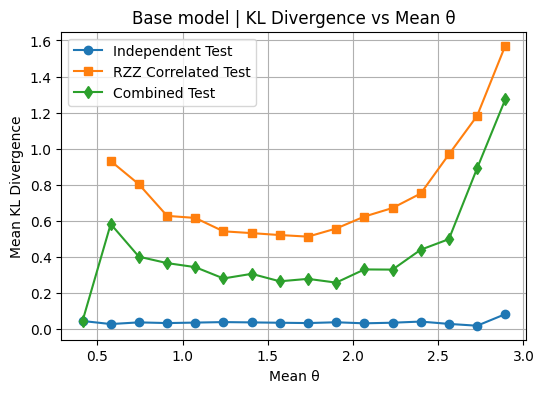

In [ ]:
# ================================
# محاسبه میانگین KL divergence بر اساس theta
# ================================
# ================================
# محاسبه برای دیتاست مستقل
# ================================
bin_centers_ind, kl_binned_ind = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_base, 'kl')
# ================================
# محاسبه برای دیتاست RZZ
# ================================
bin_centers_zz, kl_binned_zz = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_base, 'kl')
# ================================
# محاسبه برای دیتاست ترکیبی combined
# ================================
bin_centers_mix, kl_binned_mix = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_base, 'kl')
# ================================
# رسم نمودار مقایسه‌ای KL
# ================================
plt.figure(figsize=(6,4))
plt.plot(bin_centers_ind, kl_binned_ind, marker='o', label="Independent Test")
plt.plot(bin_centers_zz, kl_binned_zz, marker='s', label="RZZ Correlated Test")
plt.plot(bin_centers_mix, kl_binned_mix, marker='d', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean KL Divergence")
plt.title("Base model | KL Divergence vs Mean θ")
plt.legend()
plt.grid(True)
plt.show()

## Train / Validation / Test

In [48]:
# ================================
# GENERATE TRAIN / VALIDATION / TEST
# ================================
# print("Generating TRAIN dataset (independent)...")
# # مستقل
# X_train_ind, Y_train_ind, theta_train_ind = generate_dataset(4000, build_circuit_independent)
# # correlated
# X_train_zz, Y_train_zz, theta_train_zz = generate_dataset(2000, build_correlated_circuit)

# # ترکیب
# X_train = np.vstack([X_train_ind, X_train_zz])
# Y_train = np.vstack([Y_train_ind, Y_train_zz])
# theta_train = np.vstack([theta_train_ind, theta_train_zz])

print("Generating VALIDATION dataset (mixed)...")
# ترکیبی: 80% مستقل + 20% correlated
X_val_ind, Y_val_ind, theta_val_ind = generate_dataset(1200, build_circuit_independent)
X_val_zz, Y_val_zz, theta_val_zz = generate_dataset(800, build_correlated_circuit)

X_val = np.vstack([X_val_ind, X_val_zz])
Y_val = np.vstack([Y_val_ind, Y_val_zz])
theta_val = np.vstack([theta_val_ind, theta_val_zz])

Generating VALIDATION dataset (mixed)...


In [17]:
# save dataset related to model_mlp
# ================================
# ذخیره دیتای آموزش (train)
# ================================
np.savetxt("X_train_mlp.txt", X_train.reshape(X_train.shape[0], -1))
np.savetxt("Y_train_mlp.txt", Y_train.reshape(Y_train.shape[0], -1))
np.savetxt("theta_train_mlp.txt", theta_train)


# ================================
# ذخیره دیتای تست مستقل (Independent)
# ================================
# np.savetxt("X_test_ind_mlp.txt", X_test_ind.reshape(X_test_ind.shape[0], -1))
# np.savetxt("Y_test_ind_mlp.txt", Y_test_ind.reshape(Y_test_ind.shape[0], -1))
# np.savetxt("theta_test_ind_mlp.txt", theta_test_ind)

# ================================
# ذخیره دیتای تست همبسته (RZZ Correlated)
# ================================
# np.savetxt("X_test_zz_mlp.txt", X_test_zz.reshape(X_test_zz.shape[0], -1))
# np.savetxt("Y_test_zz_mlp.txt", Y_test_zz.reshape(Y_test_zz.shape[0], -1))
# np.savetxt("theta_test_zz_mlp.txt", theta_test_zz)

# ================================
# ذخیره دیتای تست ترکیبی (Combined)
# ================================
# np.savetxt("X_test_combined_mlp.txt", X_test_combined.reshape(X_test_combined.shape[0], -1))
# np.savetxt("Y_test_combined_mlp.txt", Y_test_combined.reshape(Y_test_combined.shape[0], -1))
# np.savetxt("theta_test_combined_mlp.txt", theta_test_combined)

In [45]:
# ================================
# بارگذاری داده‌ها برای استفاده در مدل جدید
# ================================
X_train_mlp = np.loadtxt("X_train_mlp.txt").reshape(-1, 16)
Y_train_mlp = np.loadtxt("Y_train_mlp.txt").reshape(-1, 16)
theta_train_mlp = np.loadtxt("theta_train_mlp.txt").reshape(-1, 4)

# X_val = np.loadtxt("X_val_mlp.txt").reshape(-1, 16)
# Y_val = np.loadtxt("Y_val_mlp.txt").reshape(-1, 16)
# theta_val = np.loadtxt("theta_val_mlp.txt").reshape(-1, 4)

# X_test_ind_mlp = np.loadtxt("X_test_ind_mlp.txt").reshape(-1, 16)
# Y_test_ind_mlp = np.loadtxt("Y_test_ind_mlp.txt").reshape(-1, 16)
# theta_test_ind_mlp = np.loadtxt("theta_test_ind_mlp.txt").reshape(-1, 4)

# X_test_zz_mlp = np.loadtxt("X_test_zz_mlp.txt").reshape(-1, 16)
# Y_test_zz_mlp = np.loadtxt("Y_test_zz_mlp.txt").reshape(-1, 16)
# theta_test_zz_mlp = np.loadtxt("theta_test_zz_mlp.txt").reshape(-1, 4)

# X_test_combined_mlp = np.loadtxt("X_test_combined_mlp.txt").reshape(-1, 16)
# Y_test_combined_mlp = np.loadtxt("Y_test_combined_mlp.txt").reshape(-1, 16)
# theta_test_combined_mlp = np.loadtxt("theta_test_combined_mlp.txt").reshape(-1, 4)

In [49]:
print("Loading TEST dataset (same as base model)...")
X_test_ind = np.loadtxt("X_test_ind.txt").reshape(-1,16)
Y_test_ind = np.loadtxt("Y_test_ind.txt").reshape(-1,16)
theta_test_ind = np.loadtxt("theta_test_ind.txt").reshape(-1,4)

X_test_zz = np.loadtxt("X_test_zz.txt").reshape(-1,16)
Y_test_zz = np.loadtxt("Y_test_zz.txt").reshape(-1,16)
theta_test_zz = np.loadtxt("theta_test_zz.txt").reshape(-1,4)

X_test_combined = np.loadtxt("X_test_combined.txt").reshape(-1,16)
Y_test_combined = np.loadtxt("Y_test_combined.txt").reshape(-1,16)
theta_test_combined = np.loadtxt("theta_test_combined.txt").reshape(-1,4)

Loading TEST dataset (same as base model)...


In [50]:
# ================================
# DATA LOADERS
# ================================
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_mlp,dtype=torch.float32),
                  torch.tensor(Y_train_mlp,dtype=torch.float32)),
    batch_size=64, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val,dtype=torch.float32),
                  torch.tensor(Y_val,dtype=torch.float32)),
    batch_size=64, shuffle=False)

In [51]:
# ================================
# MODEL
# ================================
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16,128), nn.ReLU(),
            nn.Linear(128,256), nn.ReLU(),
            nn.Linear(256,128), nn.ReLU(),
            nn.Linear(128,16),

            nn.Softmax(dim=1)
        )
    def forward(self, x):
        return self.net(x)


In [55]:
# ================================
# TRAINING WITH VALIDATION
# ================================
model_mlp = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)

epochs = 71
train_losses, val_losses = [], []

for epoch in range(epochs):
    # train
    model_mlp.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_mlp(x_batch)
        loss = criterion(torch.log(preds+1e-8), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))
    
    # validation
    model_mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            preds_val = model_mlp(x_val)
            loss_val = criterion(torch.log(preds_val+1e-8), y_val)
            val_loss += loss_val.item()
    val_losses.append(val_loss/len(val_loader))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train={train_losses[-1]:.5f}, Val={val_losses[-1]:.5f}")

Epoch 0: Train=0.65486, Val=0.23971
Epoch 10: Train=0.06277, Val=0.06337
Epoch 20: Train=0.04708, Val=0.04778
Epoch 30: Train=0.04145, Val=0.04393
Epoch 40: Train=0.03848, Val=0.03978
Epoch 50: Train=0.03650, Val=0.03918
Epoch 60: Train=0.03509, Val=0.03681
Epoch 70: Train=0.03407, Val=0.03563


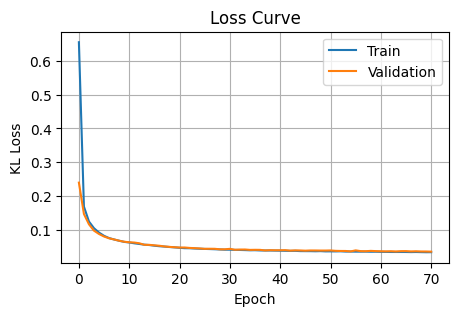

In [57]:
# ================================
# PLOT LOSS
# ================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.legend()
plt.grid(True)
plt.title("Loss Curve")
plt.show()

In [58]:
fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS_MLP =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind_mlp):<10.4f} | {np.mean(l1_ind_mlp):<10.4f} | {np.mean(kl_ind_mlp):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz_mlp):<10.4f} | {np.mean(l1_zz_mlp):<10.4f} | {np.mean(kl_zz_mlp):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix_mlp):<10.4f} | {np.mean(l1_mix_mlp):<10.4f} | {np.mean(kl_mix_mlp):<12.4f}")


===== TEST METRICS_MLP =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9769     | 0.1576     | 0.0381      
RZZ Correlated  | 0.9809     | 0.1584     | 0.0324      
Combined        | 0.9789     | 0.1580     | 0.0353      


In [29]:
fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind_mlp):<10.4f} | {np.mean(l1_ind_mlp):<10.4f} | {np.mean(kl_ind_mlp):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz_mlp):<10.4f} | {np.mean(l1_zz_mlp):<10.4f} | {np.mean(kl_zz_mlp):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix_mlp):<10.4f} | {np.mean(l1_mix_mlp):<10.4f} | {np.mean(kl_mix_mlp):<12.4f}")


===== TEST METRICS =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9791     | 0.1505     | 0.0350      
RZZ Correlated  | 0.9793     | 0.1516     | 0.0349      
Combined        | 0.9792     | 0.1510     | 0.0349      


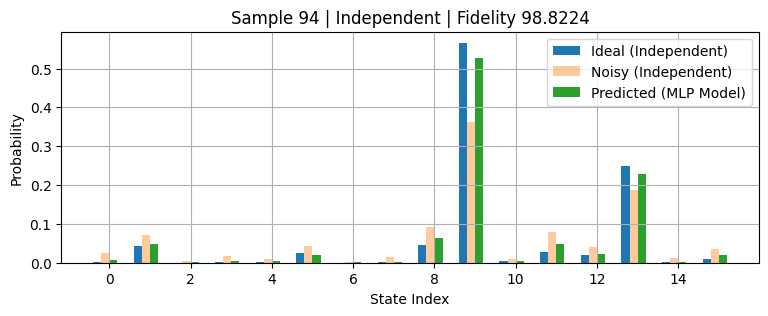

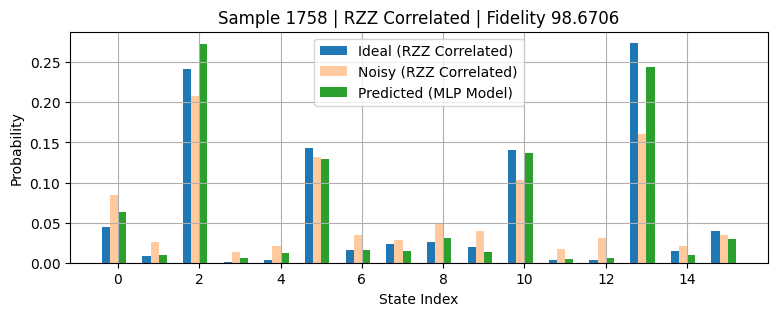

In [59]:
num_samples_to_plot = 2
indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)

x_axis = np.arange(16)
width = 0.2

for idx in indices:
    # تعیین نوع نمونه
    label_type = "Independent" if idx < len(X_test_ind) else "RZZ Correlated"
    
    plt.figure(figsize=(9,3))
    # ستون‌های نمودار
    plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
    plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    
    # پیش‌بینی مدل MLP
    pred = model_mlp(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    f = fidelity(Y_test_combined[idx], pred)
    
    plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (MLP Model)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx} | {label_type} | Fidelity {100*f:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

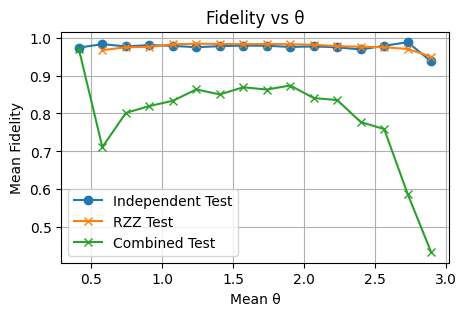

In [60]:
# ================================
# EVALUATION METRICS vs Base Model
# ================================

# Fidelity comparison
# ================================
bin_ind, fid_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'fidelity')
bin_zz, fid_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'fidelity')
bin_mix, fid_mix = compute_metric_vs_theta(X_test_combined, Y_test_combined, theta_test_combined, model_mlp, 'fidelity')

plt.figure(figsize=(5,3))
plt.plot(bin_ind, fid_ind, marker='o', label="Independent Test")
plt.plot(bin_zz, fid_zz, marker='x', label="RZZ Test")
plt.plot(bin_centers_mix, fid_binned_mix, marker='x', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Fidelity vs θ")
plt.grid(True)
plt.legend()
plt.show()

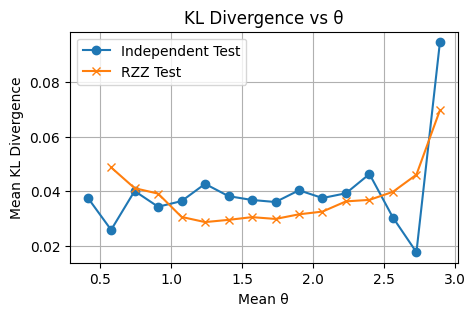

In [61]:
# ================================
# KL comparison
# ================================
bin_ind, kl_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'kl')
bin_zz, kl_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'kl')

plt.figure(figsize=(5,3))
plt.plot(bin_ind, kl_ind, marker='o', label="Independent Test")
plt.plot(bin_zz, kl_zz, marker='x', label="RZZ Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean KL Divergence")
plt.title("KL Divergence vs θ")
plt.grid(True)
plt.legend()
plt.show()

In [62]:
fidelities, l1_errors, kl_values = [], [], []

model_mlp.eval()
with torch.no_grad():
    for i in range(len(X_test_combined)):
        pred = model_mlp(torch.tensor(X_test_combined[i], dtype=torch.float32).unsqueeze(0)).numpy().flatten()
        true = Y_test_combined[i]

        fidelities.append(fidelity(true, pred))
        l1_errors.append(l1_error(true, pred))
        kl_values.append(kl_divergence(true, pred))

print("\n===== TEST METRICS =====")
print("Avg Fidelity:", np.mean(fidelities))
print("Avg L1:", np.mean(l1_errors))
print("Avg KL:", np.mean(kl_values))


===== TEST METRICS =====
Avg Fidelity: 0.9789208543991824
Avg L1: 0.1580031193335526
Avg KL: 0.03526326916600917


## Compare model_base vs model_mlp

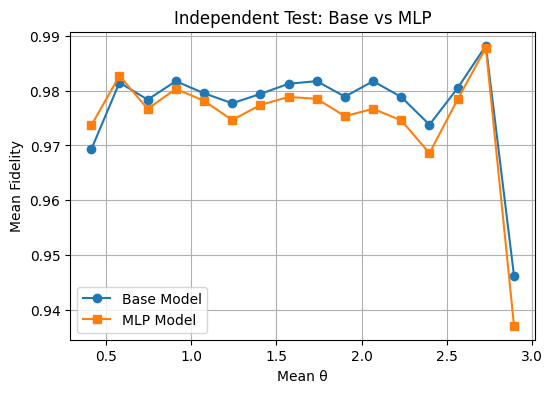

In [63]:
## Independent data
bin_ind_base, fid_ind_base = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_base, 'fidelity'
)
bin_ind_mlp, fid_ind_mlp = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_ind_base, fid_ind_base, marker='o', label="Base Model")
plt.plot(bin_ind_mlp, fid_ind_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Independent Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

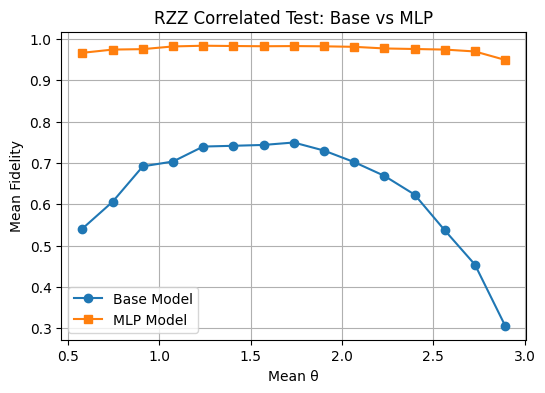

In [64]:
## ZZ data

bin_zz_base, fid_zz_base = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity'
)
bin_zz_mlp, fid_zz_mlp = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_zz_base, fid_zz_base, marker='o', label="Base Model")
plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("RZZ Correlated Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

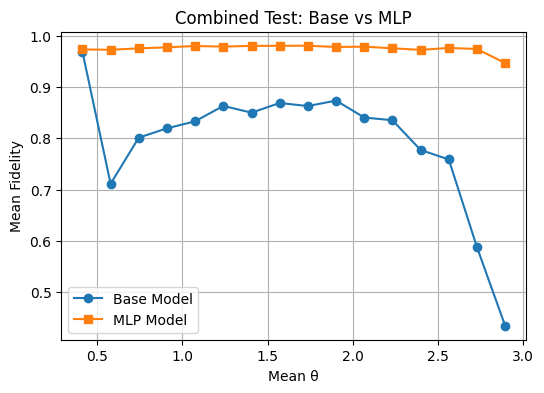

In [65]:
## combined data
bin_comb_base, fid_comb_base = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_base, 'fidelity'
)
bin_comb_mlp, fid_comb_mlp = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_comb_base, fid_comb_base, marker='o', label="Base Model")
plt.plot(bin_comb_mlp, fid_comb_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Combined Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

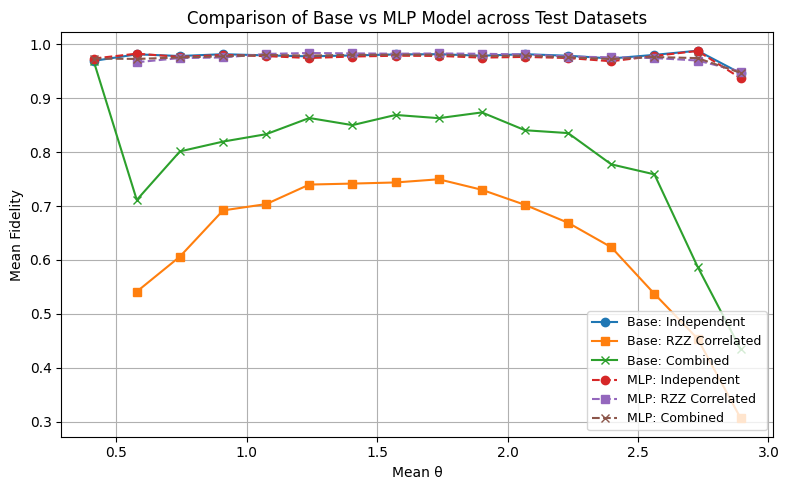

In [66]:
plt.figure(figsize=(8,5))

# Base Model
plt.plot(bin_ind_base, fid_ind_base, marker='o', linestyle='-', label="Base: Independent")
plt.plot(bin_zz_base, fid_zz_base, marker='s', linestyle='-', label="Base: RZZ Correlated")
plt.plot(bin_comb_base, fid_comb_base, marker='x', linestyle='-', label="Base: Combined")

# MLP Model
plt.plot(bin_ind_mlp, fid_ind_mlp, marker='o', linestyle='--', label="MLP: Independent")
plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', linestyle='--', label="MLP: RZZ Correlated")
plt.plot(bin_comb_mlp, fid_comb_mlp, marker='x', linestyle='--', label="MLP: Combined")

plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Comparison of Base vs MLP Model across Test Datasets")
plt.grid(True)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
# محاسبه متریک‌ها برای Base Model
fids_ind_base, l1_ind_base, kl_ind_base = evaluate_model(model_base, X_test_ind, Y_test_ind)
fids_zz_base, l1_zz_base, kl_zz_base = evaluate_model(model_base, X_test_zz, Y_test_zz)
fids_mix_base, l1_mix_base, kl_mix_base = evaluate_model(model_base, X_test_combined, Y_test_combined)

# محاسبه متریک‌ها برای MLP Model
fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)

# نمایش جدول مقایسه‌ای
print("\n===== COMPARISON: Base Model vs MLP Model =====\n")
header = f"{'Dataset':<15} | {'Metric':<10} | {'Base Model':<12} | {'MLP Model':<12}"
print(header)
print("-"*len(header))

datasets = ["Independent", "RZZ Correlated", "Combined"]
metrics = ["Fidelity", "L1 Error", "KL Divergence"]

for ds, f_base, f_mlp, l1_base, l1_mlp, kl_base, kl_mlp in zip(
    datasets,
    [np.mean(fids_ind_base), np.mean(fids_zz_base), np.mean(fids_mix_base)],
    [np.mean(fids_ind_mlp), np.mean(fids_zz_mlp), np.mean(fids_mix_mlp)],
    [np.mean(l1_ind_base), np.mean(l1_zz_base), np.mean(l1_mix_base)],
    [np.mean(l1_ind_mlp), np.mean(l1_zz_mlp), np.mean(l1_mix_mlp)],
    [np.mean(kl_ind_base), np.mean(kl_zz_base), np.mean(kl_mix_base)],
    [np.mean(kl_ind_mlp), np.mean(kl_zz_mlp), np.mean(kl_mix_mlp)]
):
    print(f"{ds:<15} | {metrics[0]:<13} | {f_base:<12.4f} | {f_mlp:<12.4f}")
    print(f"{'':<15} | {metrics[1]:<13} | {l1_base:<12.4f} | {l1_mlp:<12.4f}")
    print(f"{'':<15} | {metrics[2]:<13} | {kl_base:<12.4f} | {kl_mlp:<12.4f}")
    print("-"*len(header))


===== COMPARISON: Base Model vs MLP Model =====

Dataset         | Metric     | Base Model   | MLP Model   
----------------------------------------------------------
Independent     | Fidelity      | 0.9798       | 0.9770      
                | L1 Error      | 0.1459       | 0.1589      
                | KL Divergence | 0.0337       | 0.0377      
----------------------------------------------------------
RZZ Correlated  | Fidelity      | 0.7133       | 0.9816      
                | L1 Error      | 0.8744       | 0.1549      
                | KL Divergence | 0.5856       | 0.0312      
----------------------------------------------------------
Combined        | Fidelity      | 0.8466       | 0.9793      
                | L1 Error      | 0.5101       | 0.1569      
                | KL Divergence | 0.3097       | 0.0344      
----------------------------------------------------------
